In [3]:
%pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.9/572.9 MB 65.6 MB/s  0:00:07m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 16.2 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 83.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 72.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 17.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 71.1 MB/s  0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18/18 [tensorflow]8 [tensorflow]
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import s3fs

from tensorflow import keras
from sklearn.metrics import classification_report
from tensorflow.keras import layers

In [ ]:

# =========================================================
# 1. RECHARGEMENT DU PARQUET DEPUIS MINIO
# =========================================================
MY_BUCKET = "matheo"
CHEMIN_FICHIER_OUT = "diffusion/data/fwi_se_spain_28x28.parquet"
VALUE_COL = "fwi-daily-proj"
GRID_SIZE = 28

fs = s3fs.S3FileSystem(client_kwargs={"endpoint_url": "https://minio.lab.sspcloud.fr"})
with fs.open(f"s3://{MY_BUCKET}/{CHEMIN_FICHIER_OUT}", "rb") as f:
    df_loaded = pd.read_parquet(f)

print(f"DataFrame rechargé : {df_loaded.shape}")
print(df_loaded.head())

# =========================================================
# 2. RECONSTRUCTION DU TENSEUR (N, 28, 28)
# =========================================================

df_sorted = df_loaded.sort_values(["time", "lat", "lon"]).reset_index(drop=True)

# Vérification : chaque date doit avoir exactement 784 pixels
counts = df_sorted.groupby("time").size()
assert (counts == GRID_SIZE * GRID_SIZE).all(), \
    f"Certaines dates n'ont pas {GRID_SIZE*GRID_SIZE} pixels"

# Conversion en tenseur (N, 28, 28)
n_dates = df_sorted["time"].nunique()
X = df_sorted[VALUE_COL].values.reshape(n_dates, GRID_SIZE, GRID_SIZE)
dates = np.sort(df_sorted["time"].unique())

print(f"Tenseur X : {X.shape}")   # (N, 28, 28)
print(f"min = {X.min():.3f}, max = {X.max():.3f}, mean = {X.mean():.3f}")


DataFrame rechargé : (10308816, 4)
        time        lat       lon  fwi-daily-proj
0 1970-01-01  37.267857 -8.548214             1.0
1 1970-01-01  37.267857 -8.244643             1.0
2 1970-01-01  37.267857 -7.941071             1.0
3 1970-01-01  37.267857 -7.637500             1.0
4 1970-01-01  37.267857 -7.333929             1.0
Tenseur X : (13149, 28, 28)
min = 0.000, max = 211.122, mean = 15.011


I0000 00:00:1777069678.885026  155553 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777069678.887560  155553 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777069678.955862  155553 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777069681.306962  155553 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

x_train : (12418, 28, 28), y_train : (12418,)
x_test  : (731, 28, 28),  y_test  : (731,)
Années train : 1970–2003
Années test  : 2004–2005


E0000 00:00:1777069682.916303  155553 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 13, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │        40,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │         1,212 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,560 (166.25 KB)

 Trainable params: 42,560 (166.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.1416 - loss: 2.3666 - val_accuracy: 0.2025 - val_loss: 2.2043
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.1923 - loss: 2.1600 - val_accuracy: 0.2202 - val_loss: 1.9646
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.2053 - loss: 2.0097 - val_accuracy: 0.2380 - val_loss: 1.8695
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.2235 - loss: 1.9440 - val_accuracy: 0.2627 - val_loss: 1.8200
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.2417 - loss: 1.8999 - val_accuracy: 0.2476 - val_loss: 1.8002
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.2488 - loss: 1.8702 - val_accuracy: 0.2640 - val_loss: 1.7815
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.2666 - loss: 1.8364 - val_accuracy: 0.2640 - val_loss: 1.7529
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.2833 - loss: 1.8112 - val_accuracy: 0.2736 - v

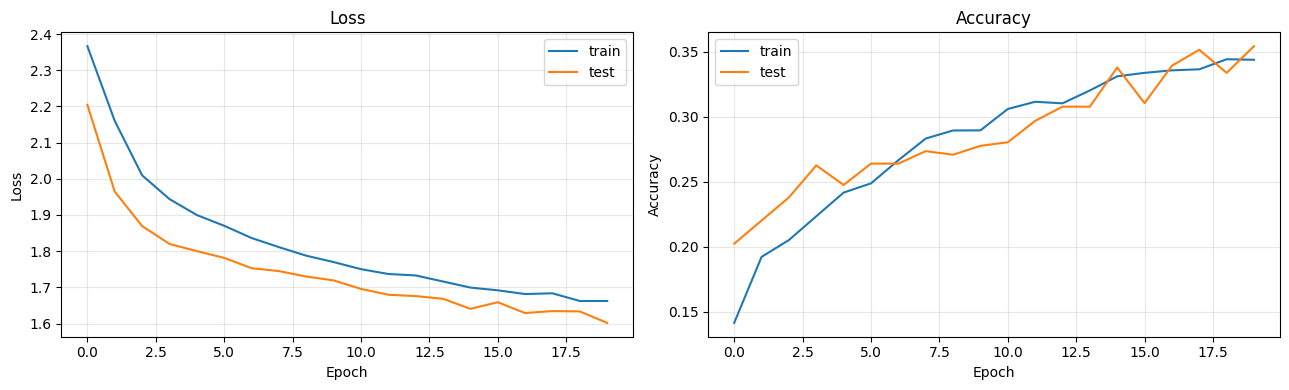


=== Classification report ===
              precision    recall  f1-score   support

         Jan      0.244     0.661     0.357        62
         Fév      0.242     0.140     0.178        57
         Mar      0.281     0.290     0.286        62
         Avr      0.417     0.417     0.417        60
         Mai      0.457     0.258     0.330        62
        Juin      0.341     0.250     0.288        60
        Juil      0.315     0.468     0.377        62
        Août      0.377     0.645     0.476        62
         Sep      0.432     0.317     0.365        60
         Oct      0.727     0.387     0.505        62
         Nov      0.425     0.283     0.340        60
         Déc      0.583     0.113     0.189        62

    accuracy                          0.354       731
   macro avg      0.404     0.352     0.342       731
weighted avg      0.405     0.354     0.343       731



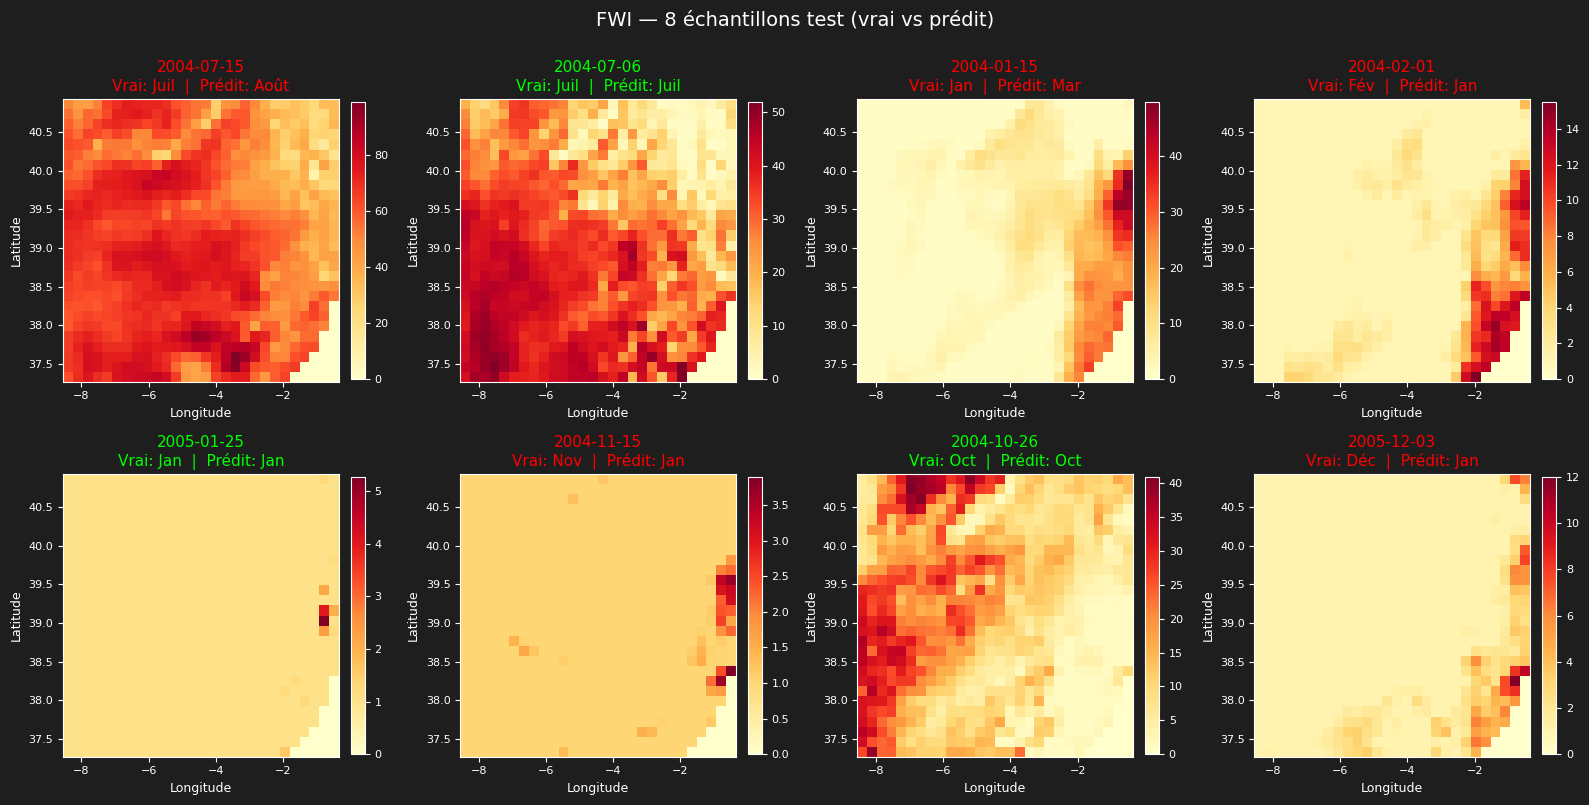

In [ ]:
# =========================================================
# CNN POUR PRÉDIRE LE MOIS À PARTIR DES IMAGES FWI 28x28
# =========================================================

# ---------------------------------------------------------
# 1. PRÉPARATION DES LABELS (mois) ET SPLIT TEMPOREL
# ---------------------------------------------------------
# X est de forme (N, 28, 28) et `dates` contient les dates triées
dates = pd.to_datetime(dates)
years = dates.year
months = dates.month - 1  

# Split temporel : train 1970-2003, test 2004-2005
train_mask = (years >= 1970) & (years <= 2003)
test_mask  = (years >= 2004) & (years <= 2005)

x_train = X[train_mask].astype("float32")
y_train = months[train_mask].astype("int64")
x_test  = X[test_mask].astype("float32")
y_test  = months[test_mask].astype("int64")

# Récupérer les coords lat/lon (constantes pour toutes les dates)
df_one_date = df_sorted[df_sorted["time"] == df_sorted["time"].iloc[0]]
lats = np.sort(df_one_date["lat"].unique())   # 28 valeurs
lons = np.sort(df_one_date["lon"].unique())   # 28 valeurs
test_dates = dates[test_mask]

print(f"x_train : {x_train.shape}, y_train : {y_train.shape}")
print(f"x_test  : {x_test.shape},  y_test  : {y_test.shape}")
print(f"Années train : {years[train_mask].min()}–{years[train_mask].max()}")
print(f"Années test  : {years[test_mask].min()}–{years[test_mask].max()}")

# ---------------------------------------------------------
# 2. NORMALISATION (stats calculées sur le train uniquement)
# ---------------------------------------------------------
x_max = x_train.max()
x_train = x_train / x_max
x_test  = x_test  / x_max

# Ajout de la dimension canal -> (N, 28, 28, 1)
x_train = x_train[..., np.newaxis]
x_test  = x_test[...,  np.newaxis]

# ---------------------------------------------------------
# 3. CONSTRUCTION DU MODÈLE CNN 
# ---------------------------------------------------------
model = keras.models.Sequential()

model.add(keras.layers.Input((28, 28, 1)))

model.add(keras.layers.Conv2D(8, (3, 3), activation='relu'))
model.add(keras.layers.MaxPooling2D((2, 2)))
model.add(keras.layers.Dropout(0.2))

model.add(keras.layers.Conv2D(16, (3, 3), activation='relu'))
model.add(keras.layers.MaxPooling2D((2, 2)))
model.add(keras.layers.Dropout(0.2))

model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(100, activation='relu'))
model.add(keras.layers.Dropout(0.5))

# 12 sorties = 12 mois
model.add(keras.layers.Dense(12, activation='softmax'))

model.summary()

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# ---------------------------------------------------------
# 4. ENTRAÎNEMENT
# ---------------------------------------------------------
batch_size = 512
epochs     = 20

history = model.fit(x_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    validation_data=(x_test, y_test),
                    verbose=1)

# ---------------------------------------------------------
# 5. AFFICHAGE DE LA LOSS
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history['loss'],     label='train')
axes[0].plot(history.history['val_loss'], label='test')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history['accuracy'],     label='train')
axes[1].plot(history.history['val_accuracy'], label='test')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 6. CLASSIFICATION REPORT (sklearn)
# ---------------------------------------------------------
y_pred_proba = model.predict(x_test, verbose=0)
y_pred = y_pred_proba.argmax(axis=1)

month_names = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Juin',
               'Juil', 'Août', 'Sep', 'Oct', 'Nov', 'Déc']

print("\n=== Classification report ===")
print(classification_report(y_test, y_pred,
                            target_names=month_names,
                            digits=3))

# ---------------------------------------------------------
# 7. AFFICHAGE DE 8 IMAGES (lat/lon) — fond #1e1e1e, cmap YlOrRd
# ---------------------------------------------------------
BG = "#1e1e1e"
np.random.seed(0)
idx = np.random.choice(len(x_test), size=8, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(16, 8), facecolor=BG)
axes = axes.ravel()

extent = [lons.min(), lons.max(), lats.min(), lats.max()]

for k, i in enumerate(idx):
    ax = axes[k]
    ax.set_facecolor(BG)

    img = x_test[i, ..., 0] * x_max  # dénormalisation pour l'affichage
    im = ax.imshow(img, cmap="YlOrRd", origin="lower", extent=extent,
                   aspect="auto")

    true_m = month_names[y_test[i]]
    pred_m = month_names[y_pred[i]]
    color = "lime" if y_test[i] == y_pred[i] else "red"
    date_str = pd.Timestamp(test_dates.iloc[i] if hasattr(test_dates, 'iloc')
                            else test_dates[i]).strftime("%Y-%m-%d")

    ax.set_title(f"{date_str}\nVrai: {true_m}  |  Prédit: {pred_m}",
                 color=color, fontsize=11)
    ax.set_xlabel("Longitude", color="white", fontsize=9)
    ax.set_ylabel("Latitude",  color="white", fontsize=9)
    ax.tick_params(colors="white", labelsize=8)
    for spine in ax.spines.values():
        spine.set_color("white")

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(colors="white", labelsize=8)
    cbar.outline.set_edgecolor("white")

plt.suptitle("FWI — 8 échantillons test (vrai vs prédit)",
             color="white", fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

x_train : (12418, 28, 28), y_train : (12418,)
x_test  : (731, 28, 28),  y_test  : (731,)
Années train : 1970–2003
Années test  : 2004–2005

Répartition train : {'Hiver': np.int64(3068), 'Printemps': np.int64(3128), 'Été': np.int64(3128), 'Automne': np.int64(3094)}
Répartition test  : {'Hiver': np.int64(181), 'Printemps': np.int64(184), 'Été': np.int64(184), 'Automne': np.int64(182)}


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_43 (Conv2D)              │ (None, 26, 26, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 13, 13, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 11, 11, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 100)            │        40,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 4)              │           404 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,752 (163.09 KB)

 Trainable params: 41,752 (163.09 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.4473 - loss: 1.2896 - val_accuracy: 0.5308 - val_loss: 1.0973
Epoch 2/40
21/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5455 - loss: 1.0726

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.5541 - loss: 1.0313 - val_accuracy: 0.5951 - val_loss: 0.9145
Epoch 3/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.5763 - loss: 0.9595 - val_accuracy: 0.6265 - val_loss: 0.8743
Epoch 4/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.5926 - loss: 0.9303 - val_accuracy: 0.6238 - val_loss: 0.8578
Epoch 5/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6008 - loss: 0.9129 - val_accuracy: 0.6703 - val_loss: 0.8433
Epoch 6/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6095 - loss: 0.9007 - val_accuracy: 0.6662 - val_loss: 0.8292
Epoch 7/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6113 - loss: 0.8994 - val_accuracy: 0.6512 - val_loss: 0.8398
Epoch 8/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6212 - loss: 0.8876 - val_accuracy: 0.6744 - val_loss: 0.8264
Epoch 9/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.6207 - loss: 0.8850 - val_accuracy: 0.6772 - val_loss: 0.

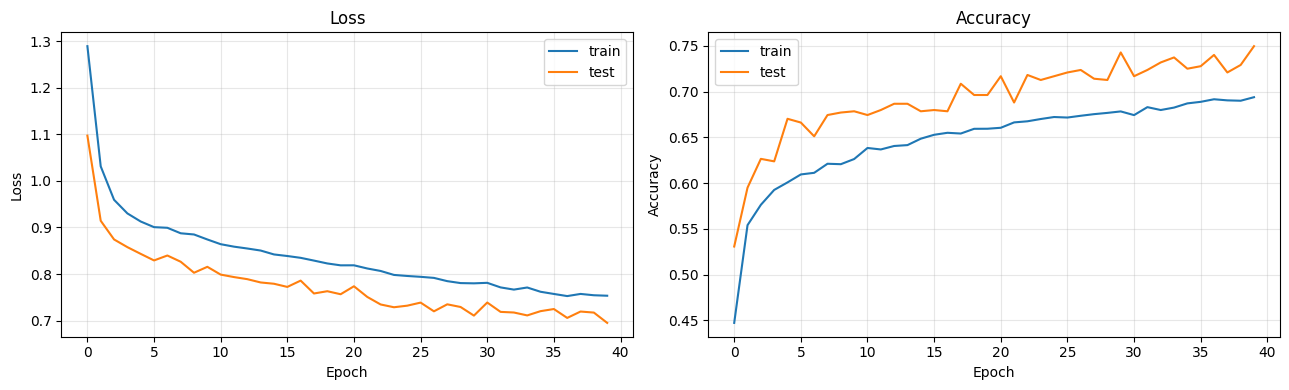


=== Classification report ===
              precision    recall  f1-score   support

       Hiver      0.719     0.934     0.812       181
   Printemps      0.851     0.620     0.717       184
         Été      0.685     0.924     0.787       184
     Automne      0.833     0.522     0.642       182

    accuracy                          0.750       731
   macro avg      0.772     0.750     0.740       731
weighted avg      0.772     0.750     0.740       731



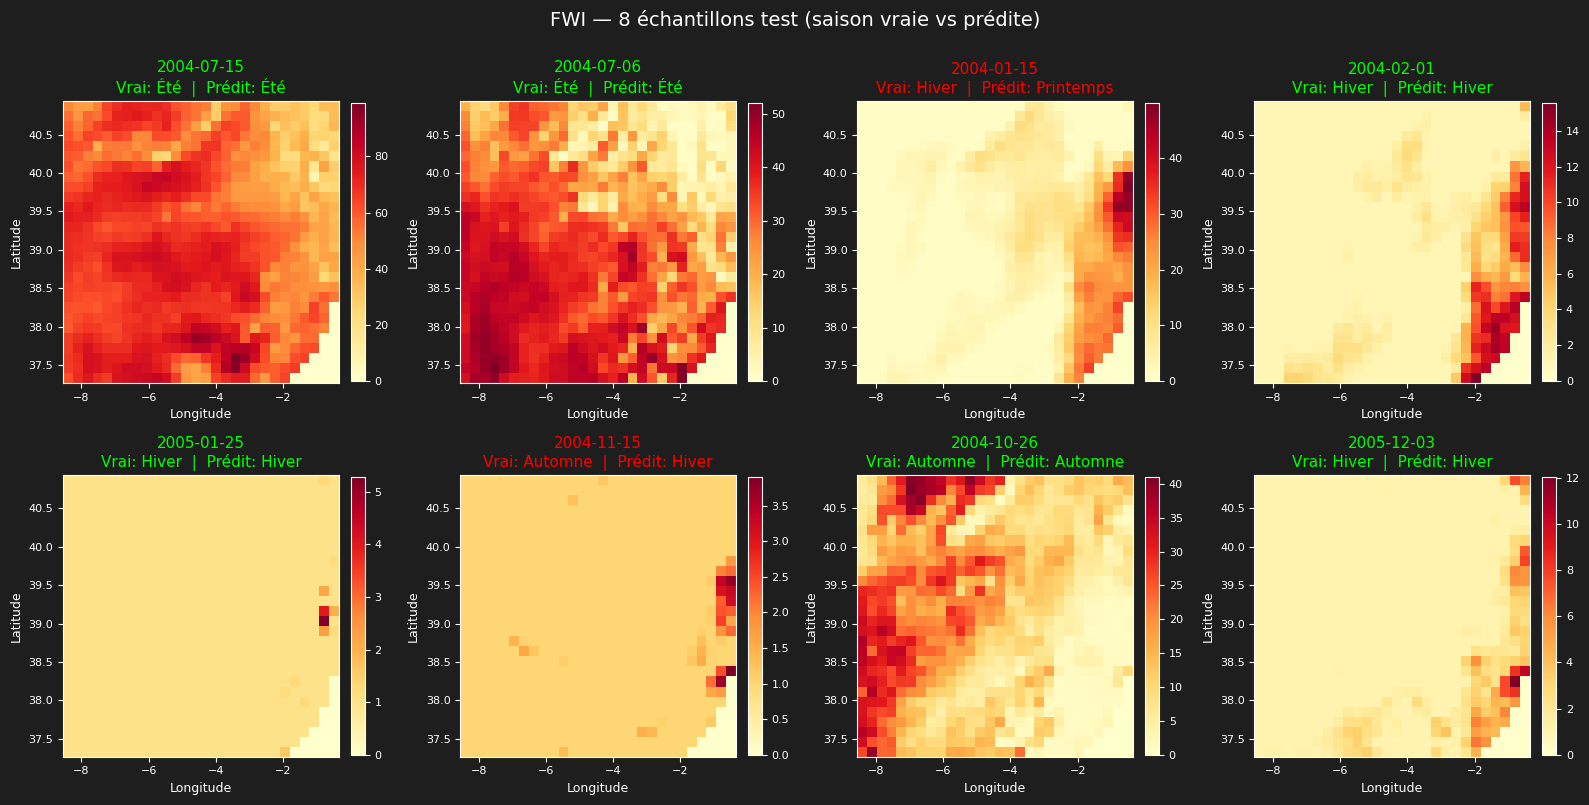

In [ ]:
# =========================================================
# CNN POUR PRÉDIRE LA SAISON À PARTIR DES IMAGES FWI 28x28
# =========================================================

# ---------------------------------------------------------
# 1. PRÉPARATION DES LABELS (saison) ET SPLIT TEMPOREL
# ---------------------------------------------------------
# X est de forme (N, 28, 28) et `dates` contient les dates triées
dates = pd.to_datetime(dates)
years = dates.year
months_num = dates.month  # 1..12

# Mapping mois -> saison (hémisphère nord)
#   Hiver    = Déc, Jan, Fév  -> 0
#   Printemps= Mar, Avr, Mai  -> 1
#   Été      = Juin, Juil, Août -> 2
#   Automne  = Sep, Oct, Nov  -> 3
def month_to_season(m):
    if m in (12, 1, 2):  return 0
    if m in (3, 4, 5):   return 1
    if m in (6, 7, 8):   return 2
    return 3  # 9, 10, 11

seasons = np.array([month_to_season(m) for m in months_num], dtype="int64")
season_names = ["Hiver", "Printemps", "Été", "Automne"]

# Split temporel : train 1970-2003, test 2004-2005
train_mask = (years >= 1970) & (years <= 2003)
test_mask  = (years >= 2004) & (years <= 2005)

x_train = X[train_mask].astype("float32")
y_train = seasons[train_mask]
x_test  = X[test_mask].astype("float32")
y_test  = seasons[test_mask]

# Coords lat/lon (constantes pour toutes les dates)
df_one_date = df_sorted[df_sorted["time"] == df_sorted["time"].iloc[0]]
lats = np.sort(df_one_date["lat"].unique())
lons = np.sort(df_one_date["lon"].unique())
test_dates = dates[test_mask]

print(f"x_train : {x_train.shape}, y_train : {y_train.shape}")
print(f"x_test  : {x_test.shape},  y_test  : {y_test.shape}")
print(f"Années train : {years[train_mask].min()}–{years[train_mask].max()}")
print(f"Années test  : {years[test_mask].min()}–{years[test_mask].max()}")

# Distribution des classes (utile pour interpréter la baseline ~25%)
print("\nRépartition train :",
      dict(zip(season_names, np.bincount(y_train, minlength=4))))
print("Répartition test  :",
      dict(zip(season_names, np.bincount(y_test, minlength=4))))

# ---------------------------------------------------------
# 2. NORMALISATION (stats calculées sur le train uniquement)
# ---------------------------------------------------------
x_max = x_train.max()
x_train = x_train / x_max
x_test  = x_test  / x_max

# Ajout de la dimension canal -> (N, 28, 28, 1)
x_train = x_train[..., np.newaxis]
x_test  = x_test[...,  np.newaxis]

# ---------------------------------------------------------
# 3. CONSTRUCTION DU MODÈLE CNN
# ---------------------------------------------------------
model = keras.models.Sequential()

model.add(keras.layers.Input((28, 28, 1)))

model.add(keras.layers.Conv2D(8, (3, 3), activation='relu'))
model.add(keras.layers.MaxPooling2D((2, 2)))
model.add(keras.layers.Dropout(0.2))

model.add(keras.layers.Conv2D(16, (3, 3), activation='relu'))
model.add(keras.layers.MaxPooling2D((2, 2)))
model.add(keras.layers.Dropout(0.2))

model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(100, activation='relu'))
model.add(keras.layers.Dropout(0.5))

# 4 sorties = 4 saisons
model.add(keras.layers.Dense(4, activation='softmax'))

model.summary()

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# ---------------------------------------------------------
# 4. ENTRAÎNEMENT
# ---------------------------------------------------------
batch_size = 512
epochs     = 40

history = model.fit(x_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    validation_data=(x_test, y_test),
                    verbose=1)

# ---------------------------------------------------------
# 5. AFFICHAGE DE LA LOSS
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history['loss'],     label='train')
axes[0].plot(history.history['val_loss'], label='test')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history['accuracy'],     label='train')
axes[1].plot(history.history['val_accuracy'], label='test')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 6. CLASSIFICATION REPORT (sklearn)
# ---------------------------------------------------------
y_pred_proba = model.predict(x_test, verbose=0)
y_pred = y_pred_proba.argmax(axis=1)

print("\n=== Classification report ===")
print(classification_report(y_test, y_pred,
                            target_names=season_names,
                            digits=3))

# ---------------------------------------------------------
# 7. AFFICHAGE DE 8 IMAGES (lat/lon) — fond #1e1e1e, cmap YlOrRd
# ---------------------------------------------------------
BG = "#1e1e1e"
np.random.seed(0)
idx = np.random.choice(len(x_test), size=8, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(16, 8), facecolor=BG)
axes = axes.ravel()

extent = [lons.min(), lons.max(), lats.min(), lats.max()]

for k, i in enumerate(idx):
    ax = axes[k]
    ax.set_facecolor(BG)

    img = x_test[i, ..., 0] * x_max  # dénormalisation pour l'affichage
    im = ax.imshow(img, cmap="YlOrRd", origin="lower", extent=extent,
                   aspect="auto")

    true_s = season_names[y_test[i]]
    pred_s = season_names[y_pred[i]]
    color = "lime" if y_test[i] == y_pred[i] else "red"
    date_str = pd.Timestamp(test_dates.iloc[i] if hasattr(test_dates, 'iloc')
                            else test_dates[i]).strftime("%Y-%m-%d")

    ax.set_title(f"{date_str}\nVrai: {true_s}  |  Prédit: {pred_s}",
                 color=color, fontsize=11)
    ax.set_xlabel("Longitude", color="white", fontsize=9)
    ax.set_ylabel("Latitude",  color="white", fontsize=9)
    ax.tick_params(colors="white", labelsize=8)
    for spine in ax.spines.values():
        spine.set_color("white")

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(colors="white", labelsize=8)
    cbar.outline.set_edgecolor("white")

plt.suptitle("FWI — 8 échantillons test (saison vraie vs prédite)",
             color="white", fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

Model: "resnet_seasons"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_34 (Conv2D)  │ (None, 28, 28,    │        144 │ input_layer_4[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │         64 │ conv2d_34[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_26 (ReLU)     │ (None, 28, 28,    │          0 │ batch_normalizat… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_35 (Conv2D)  │ (None, 28, 28,    │      2,304 │ re_lu_26[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │         64 │ conv2d_35[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_27 (ReLU)     │ (None, 28, 28,    │          0 │ batch_normalizat… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_36 (Conv2D)  │ (None, 28, 28,    │      2,304 │ re_lu_27[0][0]    │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │         64 │ conv2d_36[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_12 (Add)        │ (None, 28, 28,    │          0 │ batch_normalizat… │
│                     │ 16)               │            │ re_lu_26[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_28 (ReLU)     │ (None, 28, 28,    │          0 │ add_12[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_37 (Conv2D)  │ (None, 14, 14,    │      4,608 │ re_lu_28[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        128 │ conv2d_37[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_29 (ReLU)     │ (None, 14, 14,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_38 (Conv2D)  │ (None, 14, 14,    │      9,216 │ re_lu_29[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_39 (Conv2D)  │ (None, 14, 14,    │        512 │ re_lu_28[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        128 │ conv2d_38[0][0] 

 Total params: 78,036 (304.83 KB)

 Trainable params: 77,364 (302.20 KB)

 Non-trainable params: 672 (2.62 KB)

Epoch 1/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 233ms/step - accuracy: 0.5599 - loss: 1.0031 - val_accuracy: 0.2517 - val_loss: 1.4061
Epoch 2/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 219ms/step - accuracy: 0.6407 - loss: 0.8479 - val_accuracy: 0.2476 - val_loss: 1.5974
Epoch 3/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 221ms/step - accuracy: 0.6912 - loss: 0.7548 - val_accuracy: 0.2517 - val_loss: 1.9047
Epoch 4/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 222ms/step - accuracy: 0.7328 - loss: 0.6679 - val_accuracy: 0.2517 - val_loss: 2.4351
Epoch 5/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 223ms/step - accuracy: 0.7665 - loss: 0.5909 - val_accuracy: 0.2517 - val_loss: 3.0884
Epoch 6/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 221ms/step - accuracy: 0.7835 - loss: 0.5556 - val_accuracy: 0.2517 - val_loss: 4.1424
Epoch 7/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 220ms/step - accuracy: 0.8112 - loss: 0.4898 - val_accuracy: 0.2517 - val_loss: 6.1723
Epoch 8/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 219ms/step - accuracy: 0.8340 - loss: 0.4410 - val_accuracy: 0

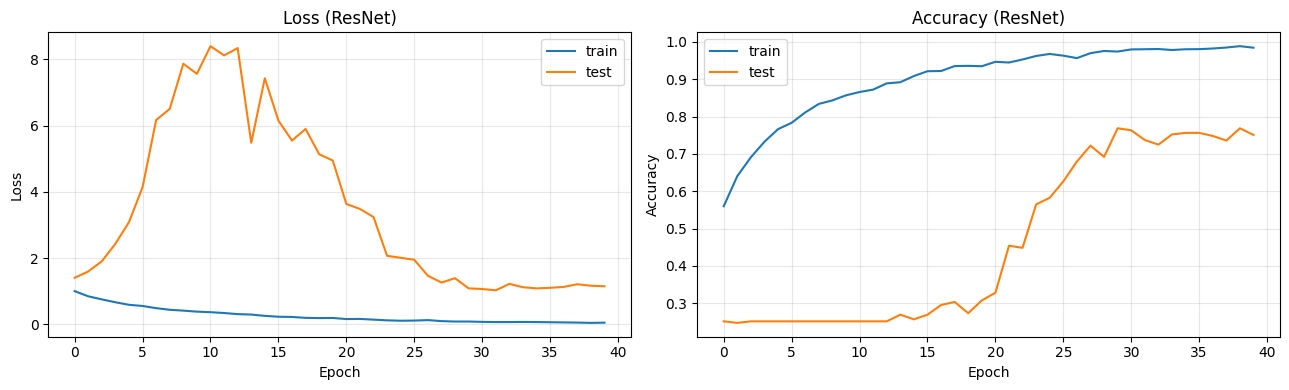


=== Classification report (ResNet) ===
              precision    recall  f1-score   support

       Hiver      0.764     0.912     0.831       181
   Printemps      0.749     0.712     0.730       184
         Été      0.799     0.755     0.777       184
     Automne      0.687     0.626     0.655       182

    accuracy                          0.751       731
   macro avg      0.750     0.751     0.748       731
weighted avg      0.750     0.751     0.748       731



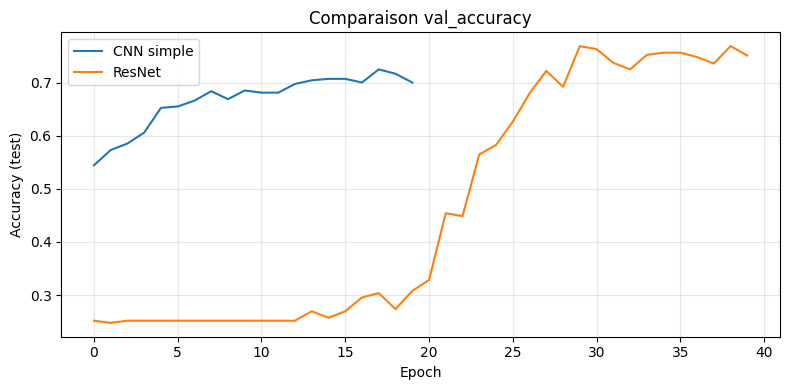

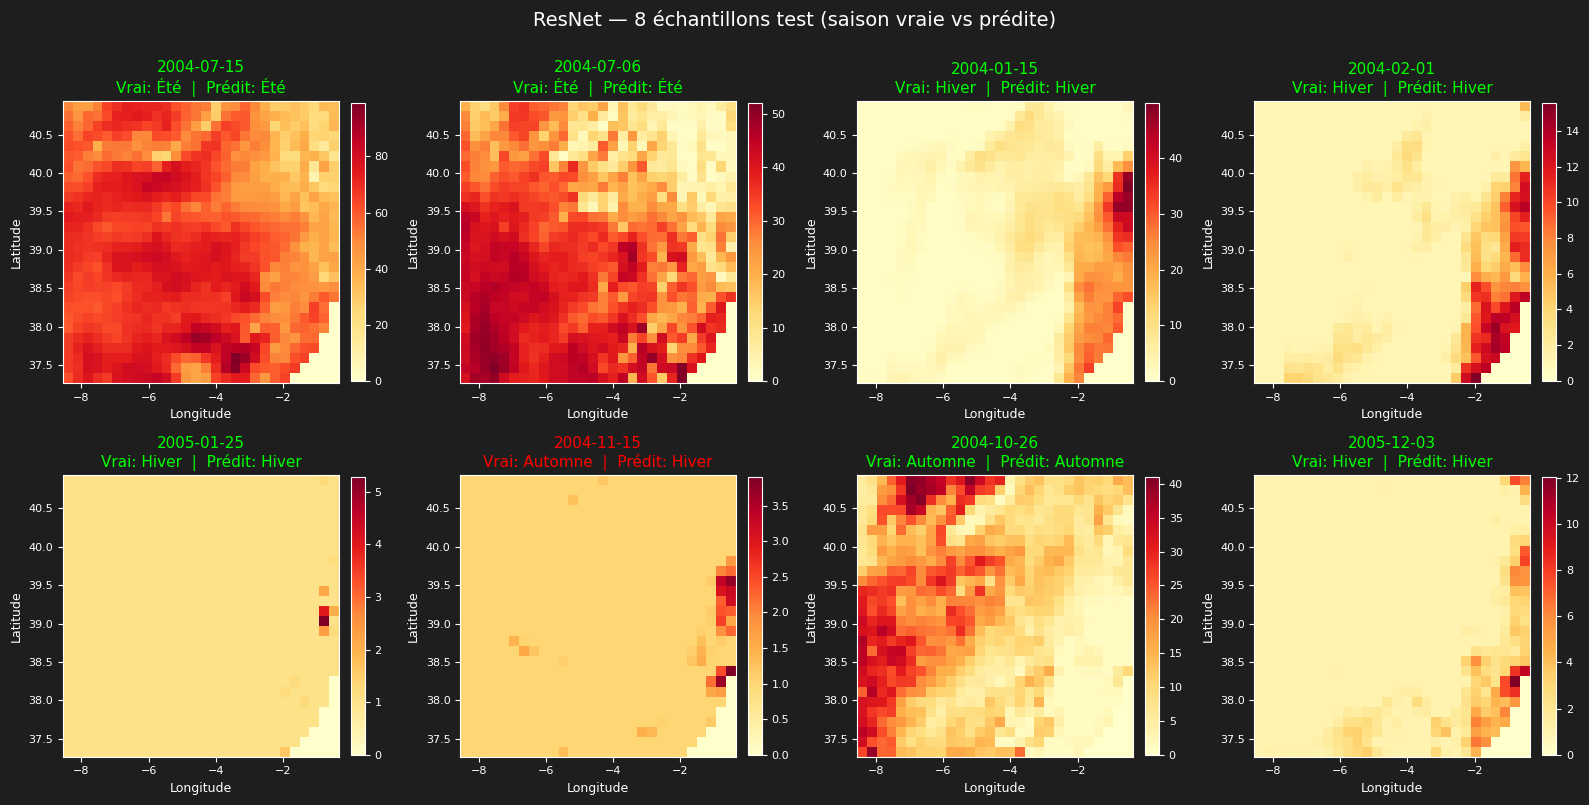

In [ ]:
# =========================================================
# VARIANTE : CNN AVEC CONNEXIONS RÉSIDUELLES (ResNet-like)
# =========================================================

# ---------------------------------------------------------
# 1. BLOC RÉSIDUEL
# ---------------------------------------------------------

def residual_block(x, filters, downsample=False):
    stride = 2 if downsample else 1
    shortcut = x

    # Branche principale F(x)
    y = layers.Conv2D(filters, (3, 3), strides=stride,
                      padding='same', use_bias=False)(x)
    y = layers.BatchNormalization()(y)
    y = layers.ReLU()(y)

    y = layers.Conv2D(filters, (3, 3), strides=1,
                      padding='same', use_bias=False)(y)
    y = layers.BatchNormalization()(y)

    # Shortcut : si la forme change (downsample ou nb de canaux différent),
    # on projette x avec une conv 1x1 pour pouvoir l'additionner.
    if downsample or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, (1, 1), strides=stride,
                                 padding='same', use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    y = layers.Add()([y, shortcut])   # connexion résiduelle
    y = layers.ReLU()(y)
    return y

# ---------------------------------------------------------
# 2. CONSTRUCTION DU MODÈLE (API fonctionnelle)
# ---------------------------------------------------------
inputs = keras.Input(shape=(28, 28, 1))

# Stem
x = layers.Conv2D(16, (3, 3), padding='same', use_bias=False)(inputs)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)

x = residual_block(x, 16)

x = residual_block(x, 32, downsample=True)

x = residual_block(x, 64, downsample=True)

# Tête de classification
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(4, activation='softmax')(x)

model_res = keras.Model(inputs, outputs, name="resnet_seasons")
model_res.summary()

model_res.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

# ---------------------------------------------------------
# 3. ENTRAÎNEMENT
# ---------------------------------------------------------
batch_size = 512
epochs     = 40

history_res = model_res.fit(x_train, y_train,
                            batch_size=batch_size,
                            epochs=epochs,
                            validation_data=(x_test, y_test),
                            verbose=1)

# ---------------------------------------------------------
# 4. AFFICHAGE DE LA LOSS / ACCURACY
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history_res.history['loss'],     label='train')
axes[0].plot(history_res.history['val_loss'], label='test')
axes[0].set_title('Loss (ResNet)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history_res.history['accuracy'],     label='train')
axes[1].plot(history_res.history['val_accuracy'], label='test')
axes[1].set_title('Accuracy (ResNet)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 5. CLASSIFICATION REPORT
# ---------------------------------------------------------
y_pred_proba_res = model_res.predict(x_test, verbose=0)
y_pred_res = y_pred_proba_res.argmax(axis=1)

print("\n=== Classification report (ResNet) ===")
print(classification_report(y_test, y_pred_res,
                            target_names=season_names,
                            digits=3))

# ---------------------------------------------------------
# 6. COMPARAISON DES DEUX MODÈLES (val accuracy par epoch)
# ---------------------------------------------------------
plt.figure(figsize=(8, 4))
plt.plot(history.history['val_accuracy'],     label='CNN simple')
plt.plot(history_res.history['val_accuracy'], label='ResNet')
plt.title("Comparaison val_accuracy")
plt.xlabel("Epoch"); plt.ylabel("Accuracy (test)")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 7. AFFICHAGE DE 8 IMAGES — fond #1e1e1e, cmap YlOrRd
# ---------------------------------------------------------
BG = "#1e1e1e"
np.random.seed(0)
idx = np.random.choice(len(x_test), size=8, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(16, 8), facecolor=BG)
axes = axes.ravel()

extent = [lons.min(), lons.max(), lats.min(), lats.max()]

for k, i in enumerate(idx):
    ax = axes[k]
    ax.set_facecolor(BG)

    img = x_test[i, ..., 0] * x_max
    im = ax.imshow(img, cmap="YlOrRd", origin="lower", extent=extent,
                   aspect="auto")

    true_s = season_names[y_test[i]]
    pred_s = season_names[y_pred_res[i]]
    color = "lime" if y_test[i] == y_pred_res[i] else "red"
    date_str = pd.Timestamp(test_dates.iloc[i] if hasattr(test_dates, 'iloc')
                            else test_dates[i]).strftime("%Y-%m-%d")

    ax.set_title(f"{date_str}\nVrai: {true_s}  |  Prédit: {pred_s}",
                 color=color, fontsize=11)
    ax.set_xlabel("Longitude", color="white", fontsize=9)
    ax.set_ylabel("Latitude",  color="white", fontsize=9)
    ax.tick_params(colors="white", labelsize=8)
    for spine in ax.spines.values():
        spine.set_color("white")

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(colors="white", labelsize=8)
    cbar.outline.set_edgecolor("white")

plt.suptitle("ResNet — 8 échantillons test (saison vraie vs prédite)",
             color="white", fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

In [14]:
%pip install keras_tuner tensorboard

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 66.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 68.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [tensorboard] [tensorboard]
Note: you may need to restart the kernel to use updated packages.


Trial 20 Complete [00h 00m 17s]
val_accuracy: 0.7578659653663635

Best val_accuracy So Far: 0.7783857583999634
Total elapsed time: 00h 05m 25s

=== Top 5 jeux d'hyperparamètres ===
Results summary
Results in kt_seasons/cnn_bayes
Showing 5 best trials
Objective(name="val_accuracy", direction="max")

Trial 13 summary
Hyperparameters:
filters_1: 16
filters_2: 16
kernel_size: 5
dense_units: 64
dropout_conv: 0.30000000000000004
dropout_dense: 0.4
learning_rate: 0.0051160841949667015
Score: 0.7783857583999634

Trial 14 summary
Hyperparameters:
filters_1: 8
filters_2: 16
kernel_size: 3
dense_units: 256
dropout_conv: 0.2
dropout_dense: 0.4
learning_rate: 0.003232156977130305
Score: 0.7783857583999634

Trial 02 summary
Hyperparameters:
filters_1: 32
filters_2: 16
kernel_size: 5
dense_units: 256
dropout_conv: 0.2
dropout_dense: 0.5
learning_rate: 0.002552929004309444
Score: 0.7770177721977234

Trial 11 summary
Hyperparameters:
filters_1: 8
filters_2: 16
kernel_size: 5
dense_units: 160
dropout_co

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 16)     │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 12, 12, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 16)       │         6,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,540 (91.95 KB)

 Trainable params: 23,540 (91.95 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.4633 - loss: 1.1217 - val_accuracy: 0.5882 - val_loss: 0.9336
Epoch 2/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.5797 - loss: 0.9650 - val_accuracy: 0.6566 - val_loss: 0.8554
Epoch 3/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.5979 - loss: 0.9256 - val_accuracy: 0.6457 - val_loss: 0.8569
Epoch 4/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6232 - loss: 0.8951 - val_accuracy: 0.7100 - val_loss: 0.7911
Epoch 5/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.6394 - loss: 0.8625 - val_accuracy: 0.6785 - val_loss: 0.7772
Epoch 6/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.6525 - loss: 0.8387 - val_accuracy: 0.6867 - val_loss: 0.7472
Epoch 7/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.6543 - loss: 0.8311 - val_accuracy: 0.6689 - val_loss: 0.7737
Epoch 8/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.6587 - loss: 0.8189 - val_accuracy: 0.7373 - v

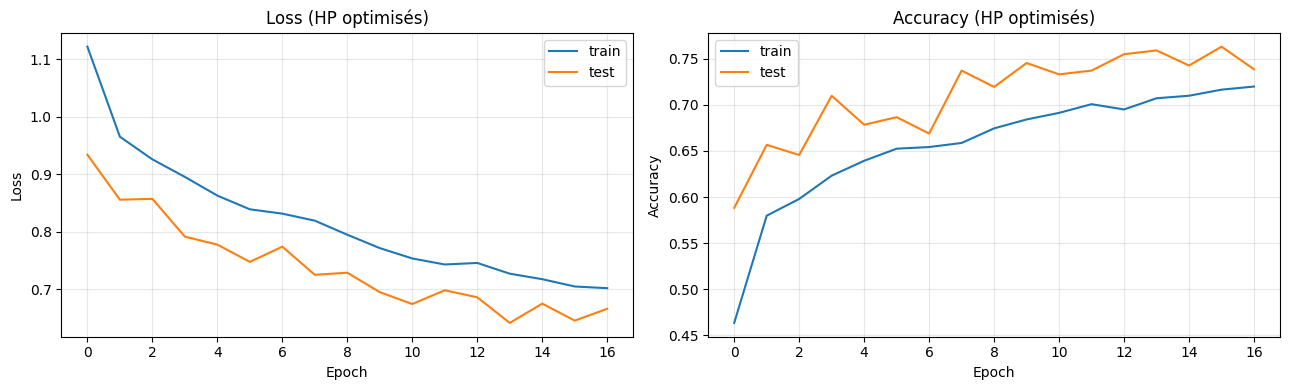


=== Classification report (CNN optimisé) ===
              precision    recall  f1-score   support

       Hiver      0.713     0.878     0.787       181
   Printemps      0.807     0.707     0.754       184
         Été      0.728     0.929     0.816       184
     Automne      0.848     0.522     0.646       182

    accuracy                          0.759       731
   macro avg      0.774     0.759     0.751       731
weighted avg      0.774     0.759     0.751       731



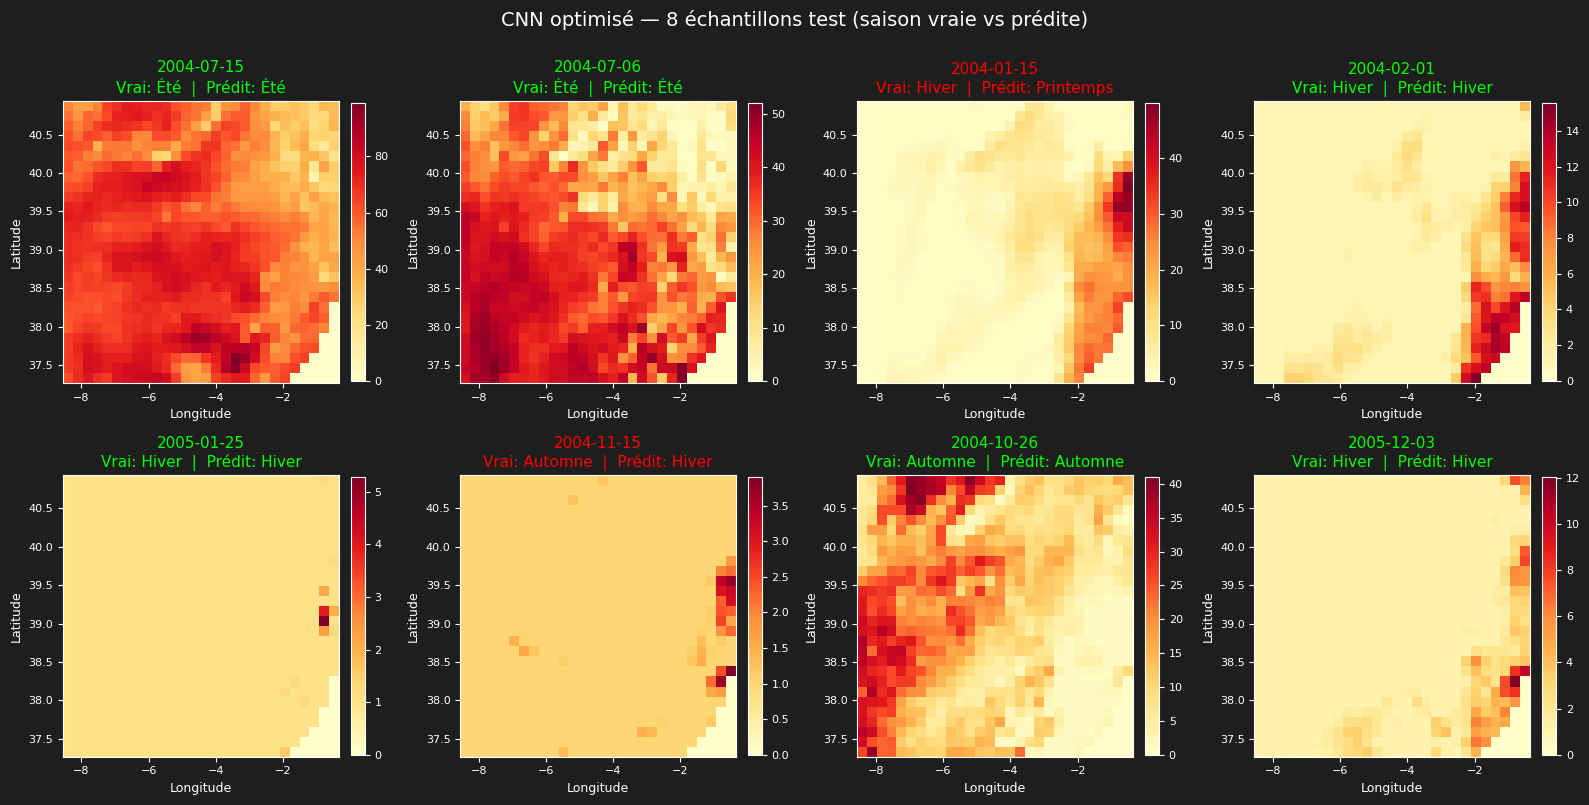

In [ ]:
# =========================================================
# OPTIMISATION BAYÉSIENNE DES HYPERPARAMÈTRES (CNN simple)
# =========================================================

import keras_tuner as kt
from tensorflow import keras

# ---------------------------------------------------------
# 1. FONCTION DE CONSTRUCTION DU MODÈLE PARAMÉTRÉ
# ---------------------------------------------------------

def build_model(hp):
    # Hyperparamètres recherchés
    filters_1   = hp.Choice("filters_1",   [8, 16, 32])
    filters_2   = hp.Choice("filters_2",   [16, 32, 64])
    kernel_size = hp.Choice("kernel_size", [3, 5])
    dense_units = hp.Int("dense_units", min_value=32, max_value=256, step=32)
    dropout_conv = hp.Float("dropout_conv", 0.0, 0.4, step=0.1)
    dropout_dense = hp.Float("dropout_dense", 0.2, 0.6, step=0.1)
    learning_rate = hp.Float("learning_rate", 1e-4, 1e-2, sampling="log")

    model = keras.models.Sequential()
    model.add(keras.layers.Input((28, 28, 1)))

    model.add(keras.layers.Conv2D(filters_1, (kernel_size, kernel_size),
                                  activation='relu'))
    model.add(keras.layers.MaxPooling2D((2, 2)))
    model.add(keras.layers.Dropout(dropout_conv))

    model.add(keras.layers.Conv2D(filters_2, (kernel_size, kernel_size),
                                  activation='relu'))
    model.add(keras.layers.MaxPooling2D((2, 2)))
    model.add(keras.layers.Dropout(dropout_conv))

    model.add(keras.layers.Flatten())
    model.add(keras.layers.Dense(dense_units, activation='relu'))
    model.add(keras.layers.Dropout(dropout_dense))
    model.add(keras.layers.Dense(4, activation='softmax'))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# ---------------------------------------------------------
# 2. CONFIGURATION DU TUNER BAYÉSIEN
# ---------------------------------------------------------

tuner = kt.BayesianOptimization(
    build_model,
    objective="val_accuracy",
    max_trials=20,           # nb de jeux d'HP testés
    num_initial_points=5,    # essais aléatoires avant le GP
    directory="kt_seasons",
    project_name="cnn_bayes",
    overwrite=True,
)

tuner.search_space_summary()

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True
)

# ---------------------------------------------------------
# 3. LANCEMENT DE LA RECHERCHE
# ---------------------------------------------------------
# Chaque essai entraîne un modèle avec un jeu d'HP différent.
# 20 essais * ~15 epochs 
tuner.search(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=20,
    batch_size=512,
    callbacks=[early_stop],
    verbose=1,
)

# ---------------------------------------------------------
# 4. AFFICHAGE DES MEILLEURS HYPERPARAMÈTRES
# ---------------------------------------------------------
print("\n=== Top 5 jeux d'hyperparamètres ===")
tuner.results_summary(num_trials=5)

best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print("\n=== Meilleurs hyperparamètres trouvés ===")
for k, v in best_hp.values.items():
    print(f"  {k:15s} = {v}")

# ---------------------------------------------------------
# 5. RÉ-ENTRAÎNEMENT FINAL AVEC LES MEILLEURS HP
# ---------------------------------------------------------

best_model = tuner.hypermodel.build(best_hp)
best_model.summary()

history_best = best_model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=40,
    batch_size=512,
    callbacks=[early_stop],
    verbose=1,
)

# ---------------------------------------------------------
# 6. LOSS / ACCURACY DU MODÈLE OPTIMISÉ
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history_best.history['loss'],     label='train')
axes[0].plot(history_best.history['val_loss'], label='test')
axes[0].set_title('Loss (HP optimisés)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history_best.history['accuracy'],     label='train')
axes[1].plot(history_best.history['val_accuracy'], label='test')
axes[1].set_title('Accuracy (HP optimisés)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 7. CLASSIFICATION REPORT
# ---------------------------------------------------------
y_pred_proba_best = best_model.predict(x_test, verbose=0)
y_pred_best = y_pred_proba_best.argmax(axis=1)

print("\n=== Classification report (CNN optimisé) ===")
print(classification_report(y_test, y_pred_best,
                            target_names=season_names,
                            digits=3))

# ---------------------------------------------------------
# 8. AFFICHAGE DE 8 IMAGES — fond #1e1e1e, cmap YlOrRd
# ---------------------------------------------------------
BG = "#1e1e1e"
np.random.seed(0)
idx = np.random.choice(len(x_test), size=8, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(16, 8), facecolor=BG)
axes = axes.ravel()

extent = [lons.min(), lons.max(), lats.min(), lats.max()]

for k, i in enumerate(idx):
    ax = axes[k]
    ax.set_facecolor(BG)

    img = x_test[i, ..., 0] * x_max
    im = ax.imshow(img, cmap="YlOrRd", origin="lower", extent=extent,
                   aspect="auto")

    true_s = season_names[y_test[i]]
    pred_s = season_names[y_pred_best[i]]
    color = "lime" if y_test[i] == y_pred_best[i] else "red"
    date_str = pd.Timestamp(test_dates.iloc[i] if hasattr(test_dates, 'iloc')
                            else test_dates[i]).strftime("%Y-%m-%d")

    ax.set_title(f"{date_str}\nVrai: {true_s}  |  Prédit: {pred_s}",
                 color=color, fontsize=11)
    ax.set_xlabel("Longitude", color="white", fontsize=9)
    ax.set_ylabel("Latitude",  color="white", fontsize=9)
    ax.tick_params(colors="white", labelsize=8)
    for spine in ax.spines.values():
        spine.set_color("white")

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(colors="white", labelsize=8)
    cbar.outline.set_edgecolor("white")

plt.suptitle("CNN optimisé — 8 échantillons test (saison vraie vs prédite)",
             color="white", fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

Trial 20 Complete [00h 00m 29s]
val_accuracy: 0.793433666229248

Best val_accuracy So Far: 0.8112174868583679
Total elapsed time: 00h 08m 30s

=== Top 5 jeux d'hyperparamètres ===
Results summary
Results in kt_seasons/cnn_bayes
Showing 5 best trials
Objective(name="val_accuracy", direction="max")

Trial 18 summary
Hyperparameters:
n_conv_blocks: 1
n_dense_layers: 1
kernel_size: 3
dropout_conv: 0.30000000000000004
dropout_dense: 0.5
learning_rate: 0.01
use_batchnorm: False
filters_0: 48
dense_units_0: 224
filters_1: 64
dense_units_1: 128
filters_2: 48
filters_3: 48
dense_units_2: 160
Score: 0.8112174868583679

Trial 07 summary
Hyperparameters:
n_conv_blocks: 2
n_dense_layers: 1
kernel_size: 3
dropout_conv: 0.30000000000000004
dropout_dense: 0.4
learning_rate: 0.008865162856655444
use_batchnorm: False
filters_0: 40
dense_units_0: 32
filters_1: 56
dense_units_1: 192
filters_2: 48
filters_3: 56
dense_units_2: 128
Score: 0.804377555847168

Trial 15 summary
Hyperparameters:
n_conv_blocks: 1


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 48)     │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 14, 14, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 224)            │     2,107,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 224)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,108,996 (8.05 MB)

 Trainable params: 2,108,996 (8.05 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.4558 - loss: 1.2499 - val_accuracy: 0.6088 - val_loss: 0.9066
Epoch 2/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.5817 - loss: 0.9624 - val_accuracy: 0.6402 - val_loss: 0.8455
Epoch 3/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.6137 - loss: 0.9205 - val_accuracy: 0.6922 - val_loss: 0.8029
Epoch 4/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.6295 - loss: 0.8907 - val_accuracy: 0.6689 - val_loss: 0.7764
Epoch 5/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.6418 - loss: 0.8573 - val_accuracy: 0.7004 - val_loss: 0.7428
Epoch 6/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.6549 - loss: 0.8380 - val_accuracy: 0.6854 - val_loss: 0.7384
Epoch 7/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.6606 - loss: 0.8224 - val_accuracy: 0.6867 - val_loss: 0.7403
Epoch 8/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.6678 - loss: 0.8039 - val_accuracy: 0.7346 - v

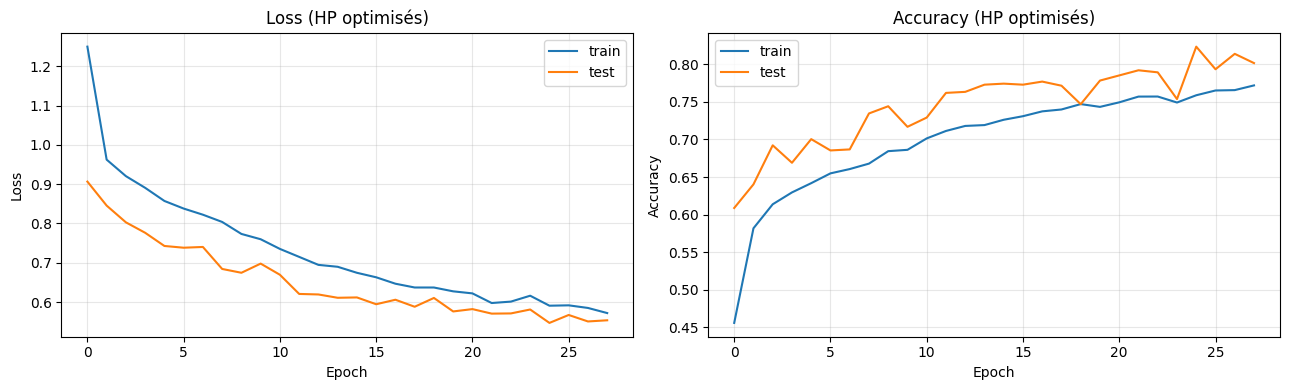


=== Classification report (CNN optimisé) ===
              precision    recall  f1-score   support

       Hiver      0.785     0.906     0.841       181
   Printemps      0.830     0.772     0.800       184
         Été      0.843     0.902     0.871       184
     Automne      0.844     0.714     0.774       182

    accuracy                          0.824       731
   macro avg      0.825     0.824     0.822       731
weighted avg      0.826     0.824     0.822       731



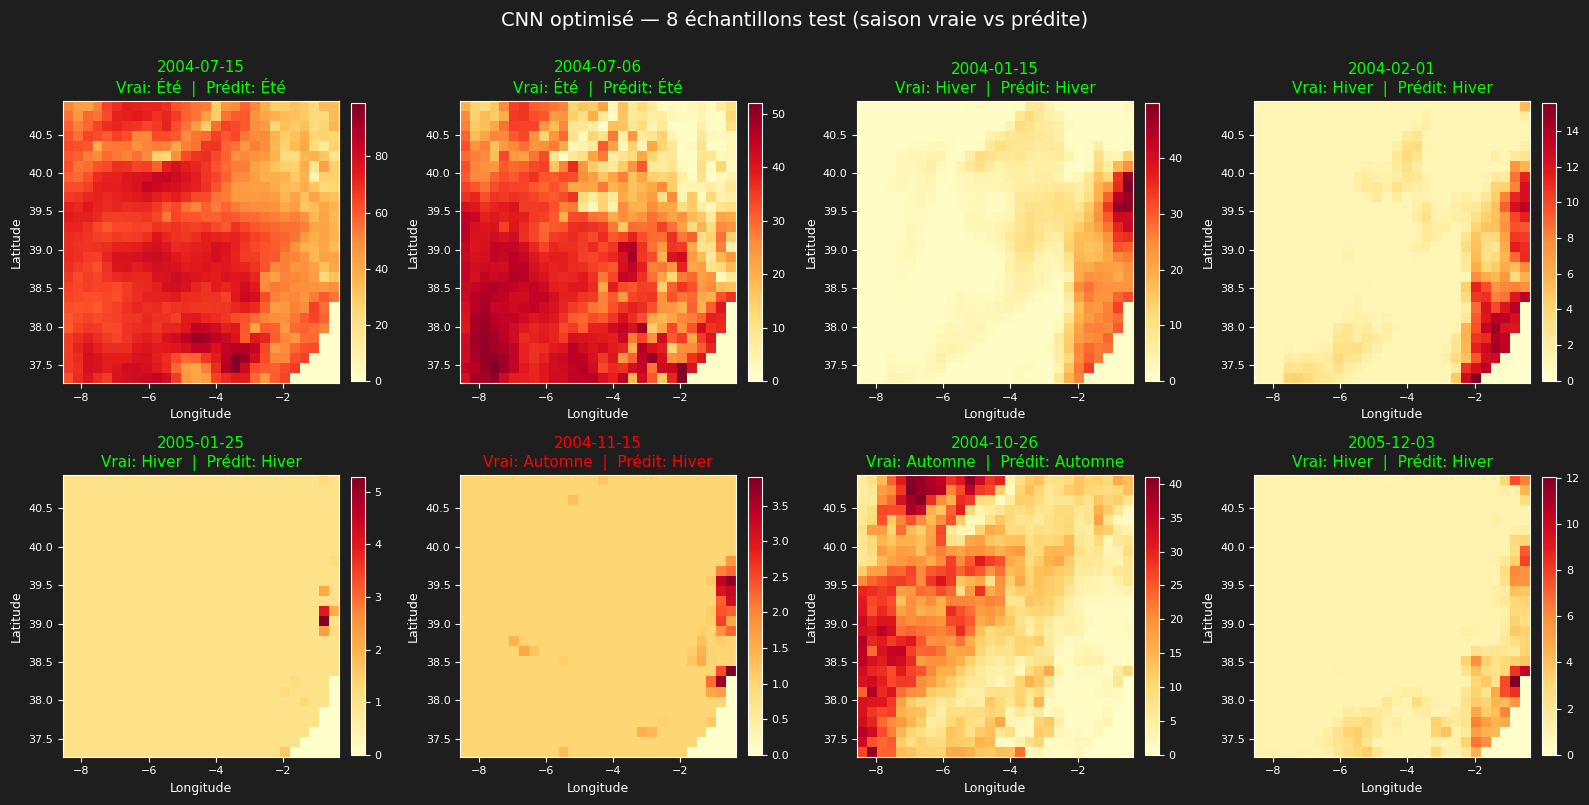

In [ ]:
# =========================================================
# OPTIMISATION BAYÉSIENNE DES HYPERPARAMÈTRES (CNN simple)
# =========================================================

import keras_tuner as kt
from tensorflow import keras

# ---------------------------------------------------------
# 1. FONCTION DE CONSTRUCTION DU MODÈLE PARAMÉTRÉ
# ---------------------------------------------------------

def build_model(hp):
    # ============================================================
    # HYPERPARAMÈTRES DE STRUCTURE (= combien de couches ?)
    # ============================================================
    n_conv_blocks  = hp.Int("n_conv_blocks",  min_value=1, max_value=4)
    n_dense_layers = hp.Int("n_dense_layers", min_value=1, max_value=3)

    # Hyperparamètres globaux
    kernel_size   = hp.Choice("kernel_size", [3, 5])
    dropout_conv  = hp.Float("dropout_conv",  0.0, 0.4, step=0.1)
    dropout_dense = hp.Float("dropout_dense", 0.2, 0.6, step=0.1)
    learning_rate = hp.Float("learning_rate", 1e-4, 1e-2, sampling="log")
    use_batchnorm = hp.Boolean("use_batchnorm")

    model = keras.models.Sequential()
    model.add(keras.layers.Input((28, 28, 1)))

    # ============================================================
    # BLOCS CONVOLUTIFS (nombre variable)
    # ============================================================

    current_size = 28  # pour éviter de pooler en dessous de 1x1
    for i in range(n_conv_blocks):
        filters = hp.Int(f"filters_{i}", min_value=8, max_value=64, step=8)

        model.add(keras.layers.Conv2D(filters, (kernel_size, kernel_size),
                                      padding='same', activation='relu'))
        if use_batchnorm:
            model.add(keras.layers.BatchNormalization())

        # On ne pool que si la feature map est encore assez grande
        if current_size >= 4:
            model.add(keras.layers.MaxPooling2D((2, 2)))
            current_size //= 2

        model.add(keras.layers.Dropout(dropout_conv))

    # ============================================================
    # COUCHES DENSES (nombre variable)
    # ============================================================
    model.add(keras.layers.Flatten())
    for j in range(n_dense_layers):
        units = hp.Int(f"dense_units_{j}",
                       min_value=32, max_value=256, step=32)
        model.add(keras.layers.Dense(units, activation='relu'))
        model.add(keras.layers.Dropout(dropout_dense))

    # Couche de sortie (fixe : 4 saisons)
    model.add(keras.layers.Dense(4, activation='softmax'))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# ---------------------------------------------------------
# 2. CONFIGURATION DU TUNER BAYÉSIEN
# ---------------------------------------------------------

tuner = kt.BayesianOptimization(
    build_model,
    objective="val_accuracy",
    max_trials=20,           # nb de jeux d'HP testés
    num_initial_points=5,    # essais aléatoires avant le GP
    directory="kt_seasons",
    project_name="cnn_bayes",
    overwrite=True,
)

tuner.search_space_summary()

# Early stopping pour ne pas perdre de temps sur les mauvais essais
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True
)

# ---------------------------------------------------------
# 3. LANCEMENT DE LA RECHERCHE
# ---------------------------------------------------------

tuner.search(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=20,
    batch_size=512,
    callbacks=[early_stop],
    verbose=1,
)

# ---------------------------------------------------------
# 4. AFFICHAGE DES MEILLEURS HYPERPARAMÈTRES
# ---------------------------------------------------------
print("\n=== Top 5 jeux d'hyperparamètres ===")
tuner.results_summary(num_trials=5)

best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print("\n=== Meilleurs hyperparamètres trouvés ===")
for k, v in best_hp.values.items():
    print(f"  {k:15s} = {v}")

# ---------------------------------------------------------
# 5. RÉ-ENTRAÎNEMENT FINAL AVEC LES MEILLEURS HP
# ---------------------------------------------------------

best_model = tuner.hypermodel.build(best_hp)
best_model.summary()

history_best = best_model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=40,
    batch_size=512,
    callbacks=[early_stop],
    verbose=1,
)

# ---------------------------------------------------------
# 6. LOSS / ACCURACY DU MODÈLE OPTIMISÉ
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history_best.history['loss'],     label='train')
axes[0].plot(history_best.history['val_loss'], label='test')
axes[0].set_title('Loss (HP optimisés)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history_best.history['accuracy'],     label='train')
axes[1].plot(history_best.history['val_accuracy'], label='test')
axes[1].set_title('Accuracy (HP optimisés)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 7. CLASSIFICATION REPORT
# ---------------------------------------------------------
y_pred_proba_best = best_model.predict(x_test, verbose=0)
y_pred_best = y_pred_proba_best.argmax(axis=1)

print("\n=== Classification report (CNN optimisé) ===")
print(classification_report(y_test, y_pred_best,
                            target_names=season_names,
                            digits=3))

# ---------------------------------------------------------
# 8. AFFICHAGE DE 8 IMAGES — fond #1e1e1e, cmap YlOrRd
# ---------------------------------------------------------
BG = "#1e1e1e"
np.random.seed(0)
idx = np.random.choice(len(x_test), size=8, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(16, 8), facecolor=BG)
axes = axes.ravel()

extent = [lons.min(), lons.max(), lats.min(), lats.max()]

for k, i in enumerate(idx):
    ax = axes[k]
    ax.set_facecolor(BG)

    img = x_test[i, ..., 0] * x_max
    im = ax.imshow(img, cmap="YlOrRd", origin="lower", extent=extent,
                   aspect="auto")

    true_s = season_names[y_test[i]]
    pred_s = season_names[y_pred_best[i]]
    color = "lime" if y_test[i] == y_pred_best[i] else "red"
    date_str = pd.Timestamp(test_dates.iloc[i] if hasattr(test_dates, 'iloc')
                            else test_dates[i]).strftime("%Y-%m-%d")

    ax.set_title(f"{date_str}\nVrai: {true_s}  |  Prédit: {pred_s}",
                 color=color, fontsize=11)
    ax.set_xlabel("Longitude", color="white", fontsize=9)
    ax.set_ylabel("Latitude",  color="white", fontsize=9)
    ax.tick_params(colors="white", labelsize=8)
    for spine in ax.spines.values():
        spine.set_color("white")

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(colors="white", labelsize=8)
    cbar.outline.set_edgecolor("white")

plt.suptitle("CNN optimisé — 8 échantillons test (saison vraie vs prédite)",
             color="white", fontsize=14, y=1.00)
plt.tight_layout()
plt.show()